untuk mengerjakan skripsi penerjemah bahasa isyarat sibi mengunakan cnn dan lstm

# import library

In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)


In [ ]:
import cv2
import os
import numpy as np
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import mediapipe as mp
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, TimeDistributed, Flatten, LSTM, Dense, Dropout, Input, GlobalAveragePooling2D,BatchNormalization
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
import shutil
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Akuisisi Data

## memanggil folder data

In [ ]:
# Tentukan path ke folder 'raw' Anda. Sesuaikan jika folder 'raw' berada di subfolder lain.
raw_folder_path = '/content/drive/MyDrive/raw'

# Periksa apakah folder tersebut ada
if os.path.exists(raw_folder_path):
    print(f"Folder 'raw' ditemukan di: {raw_folder_path}")
    # Anda bisa mulai memproses file di dalam folder 'raw'
    # Misalnya, tampilkan daftar isinya yang diurutkan secara abjad:
    print("Isi folder 'raw' (urutan abjad):")
    for item in sorted(os.listdir(raw_folder_path)): # Menggunakan sorted() untuk mengurutkan secara abjad
        print(item)
else:
    print(f"Folder 'raw' tidak ditemukan di: {raw_folder_path}")
    print("Pastikan folder 'raw' ada di Google Drive Anda dan path yang diberikan sudah benar.")

Folder 'raw' ditemukan di: /content/drive/MyDrive/raw
Isi folder 'raw' (urutan abjad):
akhiran-an
akhiran-i
akhiran-kan
akhiran-man
akhiran-nya
akhiran-ti
akhiran-wan
akhiran-wati
apa
awalan-ber
awalan-di
awalan-ke
awalan-me
awalan-pe
awalan-se
awalan-ter
baca
bagaimana
balai
bantu
bawa
beli
benar
berapa
bicara
bisa
buka
buku
cari
datang
dengar
desa
dia
dosen
duduk
gedung
guna
guru
hari
ingat
ini
itu
jalan
jalan-jalan
jawab
kamar
kami
kamu
kapan
keluarga
kendaraan
kerja
kita
kursi
lihat
lupa
makan
malam
mana
mau
meja
mengapa
mereka
minum
motor
mudah
mulai
nanti
nasi
orang
pagi
partike-pun
partikel-kah
partikel-lah
pasar
pergi
perlu
rumah
salah
satu
saya
sedih
sekarang
sekolah
selamat
selesai
senang
siapa
sore
suka
sulit
tahu
tanya
tas
teh
telepon
teman
tidur
tinggal
toko
tunggu
tutup
uang
waktu


# Preprocessing

In [ ]:
root_raw_dir = raw_folder_path
output_root = 'data/processed'

num_frames_to_save = 20
target_size = (128,128)


for label in sorted(os.listdir(root_raw_dir)):

    word_path = os.path.join(root_raw_dir, label)

    if not os.path.isdir(word_path):
        continue

    print(f"Processing label: {label}")

    output_label_dir = os.path.join(output_root, label)

    os.makedirs(output_label_dir, exist_ok=True)

    for video_name in sorted(os.listdir(word_path)):

        if not video_name.lower().endswith('.webm') and not video_name.lower().endswith('.mp4'):
            continue

        video_full_path = os.path.join(word_path, video_name)
        video_base_name = os.path.splitext(video_name)[0]

        cap = cv2.VideoCapture(video_full_path)

        if not cap.isOpened():
            print(f"Gagal membuka video: {video_name}")
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            print(f"Video rusak: {video_name}")
            cap.release()
            continue

        step = max(1, total_frames // num_frames_to_save)

        for i in range(num_frames_to_save):

            frame_id = i * step
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)

            ret, frame = cap.read()
            if not ret:
                break

            frame_res = cv2.resize(frame, target_size)

            h, w = frame_res.shape[:2]
            # crop hanya yang berkestensi .webm
            if video_name.lower().endswith('.webm'):
              crop_top = int(h * 0.25)
              frame_crop = frame_res[crop_top:h, 0:w]
            else:
              frame_crop = frame_res

            # resize lagi agar tetap 128x128
            frame_crop = cv2.resize(frame_crop, target_size)

            # Save RGB frame
            rgb_name = f"{video_base_name}_f{i:02d}.jpg"
            cv2.imwrite(os.path.join(output_label_dir, rgb_name), frame_crop)

        cap.release()

        print(f"   selesai: {video_name}")

print("\nSemua video selesai diproses.")

Processing label: akhiran-an
   selesai: Akhiran-An-cam-1.mp4
   selesai: Akhiran-An.webm
   selesai: akhiran-an-cam-2.mp4
Processing label: akhiran-i
   selesai: Akhiran-I-cam-1.mp4
   selesai: Akhiran-I.webm
   selesai: akhiran-i-cam-2.mp4
Processing label: akhiran-kan
   selesai: Akhiran-Kan-cam-1.mp4
   selesai: Akhiran-Kan.webm
   selesai: akhiran-kan-cam-2.mp4
Processing label: akhiran-man
   selesai: Akhiran-Man-cam-1.mp4
   selesai: Akhiran-Man.webm
   selesai: akhiran-man-cam-2.mp4
Processing label: akhiran-nya
   selesai: Akhiran-Nya-cam-1.mp4
   selesai: Akhiran-Nya.webm
   selesai: akhiran-nya-cam-2.mp4
Processing label: akhiran-ti
   selesai: Akhiran-Ti-cam-1.mp4
   selesai: Akhiran-Ti.webm
   selesai: akhiran-ti-cam-2.mp4
Processing label: akhiran-wan
   selesai: Akhiran-Wan-cam-1.mp4
   selesai: Akhiran-Wan.webm
   selesai: akhiran-wan-cam-2.mp4
Processing label: akhiran-wati
   selesai: Akhiran-Wati-cam-1.mp4
   selesai: Akhiran-Wati.webm
   selesai: akhiran-wati-cam-2.

# Data Cleaning

In [ ]:
INPUT_HANDS_DIR = 'data/processed'

def clean_hand_images(input_dir):
    print("Starting hand image cleaning...")
    deleted_count = 0
    total_images = 0

    for label in sorted(os.listdir(input_dir)):
        label_path = os.path.join(input_dir, label)

        if not os.path.isdir(label_path):
            continue

        print(f"  Cleaning label: {label}")

        for img_name in sorted(os.listdir(label_path)):
            total_images += 1
            img_full_path = os.path.join(label_path, img_name)

            try:
                img = cv2.imread(img_full_path)

                # Check for corrupted files (img is None if imread fails)
                if img is None:
                    print(f"    Deleting corrupted/unreadable image: {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

                # Check for empty images (shouldn't happen if imread works, but as a safeguard)
                if img.size == 0:
                    print(f"    Deleting empty image: {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

                # Check if the image is mostly black (indicating no hand or failed extraction)
                if np.mean(img) < 10:
                    print(f"    Deleting mostly black image (likely no hand): {img_full_path}")
                    os.remove(img_full_path)
                    deleted_count += 1
                    continue

            except Exception as e:
                print(f"    Error processing {img_full_path}: {e}. Deleting file.")
                os.remove(img_full_path)
                deleted_count += 1
                continue

    print(f"Cleaning complete. Total images checked: {total_images}, Deleted: {deleted_count}")

clean_hand_images(INPUT_HANDS_DIR)

Starting hand image cleaning...
  Cleaning label: akhiran-an
  Cleaning label: akhiran-i
  Cleaning label: akhiran-kan
  Cleaning label: akhiran-man
  Cleaning label: akhiran-nya
  Cleaning label: akhiran-ti
  Cleaning label: akhiran-wan
  Cleaning label: akhiran-wati
  Cleaning label: apa
  Cleaning label: awalan-ber
  Cleaning label: awalan-di
  Cleaning label: awalan-ke
  Cleaning label: awalan-me
  Cleaning label: awalan-pe
  Cleaning label: awalan-se
  Cleaning label: awalan-ter
  Cleaning label: baca
  Cleaning label: bagaimana
  Cleaning label: balai
  Cleaning label: bantu
  Cleaning label: bawa
  Cleaning label: beli
  Cleaning label: benar
  Cleaning label: berapa
  Cleaning label: bicara
  Cleaning label: bisa
  Cleaning label: buka
  Cleaning label: buku
  Cleaning label: cari
  Cleaning label: datang
  Cleaning label: dengar
  Cleaning label: desa
  Cleaning label: dia
  Cleaning label: dosen
  Cleaning label: duduk
  Cleaning label: gedung
  Cleaning label: guna
  Cleanin

# Ekstraksi fitur

## media pipe

In [ ]:
# =========================
# MEDIAPIPE SETUP
# =========================
mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

# =========================
# CROP HAND FUNCTION
# =========================
def crop_and_save_hand_images(
    image_path,
    output_dir,
    label,
    target_size=(128, 128)
):

    os.makedirs(output_dir, exist_ok=True)

    img = cv2.imread(image_path)

    if img is None:
        print(f"Gagal memuat gambar: {image_path}")
        return []

    # convert BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = hands.process(img_rgb)

    cropped_hand_paths = []

    if results.multi_hand_landmarks:

        h, w, _ = img.shape

        for i, hand_landmarks in enumerate(results.multi_hand_landmarks):

            # ambil semua titik landmark
            x_list = []
            y_list = []

            for lm in hand_landmarks.landmark:
                x_list.append(int(lm.x * w))
                y_list.append(int(lm.y * h))

            # bounding box
            x_min = max(min(x_list) - 20, 0)
            y_min = max(min(y_list) - 20, 0)

            x_max = min(max(x_list) + 20, w)
            y_max = min(max(y_list) + 20, h)

            cropped_hand = img[y_min:y_max, x_min:x_max]

            # validasi crop
            if cropped_hand.shape[0] > 0 and cropped_hand.shape[1] > 0:

                resized_hand = cv2.resize(cropped_hand, target_size)

                output_filename = os.path.join(
                    output_dir,
                    f"{label}_{os.path.basename(image_path).split('.')[0]}_hand_{i}.jpg"
                )

                cv2.imwrite(output_filename, resized_hand)

                cropped_hand_paths.append(output_filename)

            else:
                print(f"Crop kosong: {image_path}")

    return cropped_hand_paths

# =========================
# MAIN PROCESS
# =========================
INPUT_BASE_DIR = 'data/processed'
OUTPUT_HANDS_DIR = 'data/hands'

os.makedirs(OUTPUT_HANDS_DIR, exist_ok=True)

print(f"Memulai crop tangan dari '{INPUT_BASE_DIR}' ke '{OUTPUT_HANDS_DIR}'")

total_processed_images = 0
total_cropped_hands = 0

for label in sorted(os.listdir(INPUT_BASE_DIR)):

    label_input_path = os.path.join(INPUT_BASE_DIR, label)

    if not os.path.isdir(label_input_path):
        continue

    label_output_path = os.path.join(OUTPUT_HANDS_DIR, label)

    os.makedirs(label_output_path, exist_ok=True)

    print(f"\nProcessing label: {label}")

    for img_name in sorted(os.listdir(label_input_path)):

        img_full_path = os.path.join(label_input_path, img_name)

        total_processed_images += 1

        cropped_files = crop_and_save_hand_images(
            img_full_path,
            label_output_path,
            label
        )

        if cropped_files:
            total_cropped_hands += len(cropped_files)

print("\nProses selesai.")
print(f"Total gambar diproses: {total_processed_images}")
print(f"Total tangan tersimpan: {total_cropped_hands}")

Memulai crop tangan dari 'data/processed' ke 'data/hands'

Processing label: akhiran-an


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '



Processing label: akhiran-i

Processing label: akhiran-kan

Processing label: akhiran-man

Processing label: akhiran-nya

Processing label: akhiran-ti

Processing label: akhiran-wan

Processing label: akhiran-wati

Processing label: apa

Processing label: awalan-ber

Processing label: awalan-di

Processing label: awalan-ke

Processing label: awalan-me

Processing label: awalan-pe

Processing label: awalan-se

Processing label: awalan-ter

Processing label: baca

Processing label: bagaimana

Processing label: balai

Processing label: bantu

Processing label: bawa

Processing label: beli

Processing label: benar

Processing label: berapa

Processing label: bicara

Processing label: bisa

Processing label: buka

Processing label: buku

Processing label: cari

Processing label: datang

Processing label: dengar

Processing label: desa

Processing label: dia

Processing label: dosen

Processing label: duduk

Processing label: gedung

Processing label: guna

Processing label: guru

Processin

# Oversampling untuk label yang sedikit

In [ ]:
# CONFIG
DATASET_PATH = "data/hands"

TARGET_MIN = 20

# OVERSAMPLING
for label in sorted(os.listdir(DATASET_PATH)):

    label_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(label_path):
        continue

    files = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    total = len(files)

    print(f"{label}: {total}")

    # skip jika sudah cukup
    if total >= TARGET_MIN:
        continue

    print(f"Menambah data untuk label: {label}")

    counter = total

    while counter < TARGET_MIN:

        # pilih file random
        src_file = random.choice(files)

        src_path = os.path.join(label_path, src_file)

        # nama file baru
        filename, ext = os.path.splitext(src_file)

        new_filename = f"{filename}_copy_{counter}{ext}"

        dst_path = os.path.join(label_path, new_filename)

        # copy file
        shutil.copy(src_path, dst_path)

        counter += 1

    print(f"Selesai → total sekarang: {counter}")

print("\nOversampling selesai.")

akhiran-an: 39
akhiran-i: 31
akhiran-kan: 27
akhiran-man: 31
akhiran-nya: 31
akhiran-ti: 36
akhiran-wan: 23
akhiran-wati: 26
apa: 33
awalan-ber: 28
awalan-di: 32
awalan-ke: 25
awalan-me: 36
awalan-pe: 20
awalan-se: 32
awalan-ter: 21
baca: 29
bagaimana: 23
balai: 19
Menambah data untuk label: balai
Selesai → total sekarang: 20
bantu: 20
bawa: 25
beli: 17
Menambah data untuk label: beli
Selesai → total sekarang: 20
benar: 24
berapa: 29
bicara: 38
bisa: 23
buka: 22
buku: 24
cari: 26
datang: 37
dengar: 31
desa: 35
dia: 31
dosen: 29
duduk: 32
gedung: 27
guna: 30
guru: 22
hari: 36
ingat: 25
ini: 21
itu: 14
Menambah data untuk label: itu
Selesai → total sekarang: 20
jalan: 19
Menambah data untuk label: jalan
Selesai → total sekarang: 20
jalan-jalan: 20
jawab: 16
Menambah data untuk label: jawab
Selesai → total sekarang: 20
kamar: 19
Menambah data untuk label: kamar
Selesai → total sekarang: 20
kami: 15
Menambah data untuk label: kami
Selesai → total sekarang: 20
kamu: 24
kapan: 19
Menambah da

# Augmentasi
untuk memperkaya data pelatihan

## Augmentasi RGB

In [ ]:
INPUT_DIR = "data/hands"
OUTPUT_DIR = "data/augmented"

os.makedirs(OUTPUT_DIR, exist_ok=True)

for label in sorted(os.listdir(INPUT_DIR)):

    label_path = os.path.join(INPUT_DIR, label)

    if not os.path.isdir(label_path):
        continue

    output_label_path = os.path.join(OUTPUT_DIR, label)

    os.makedirs(output_label_path, exist_ok=True)

    print("Processing label:", label)

    for img_name in sorted(os.listdir(label_path)):

        img_path = os.path.join(label_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        base_name = os.path.splitext(img_name)[0]

        # ORIGINAL
        cv2.imwrite(os.path.join(output_label_path, base_name + "_orig.jpg"), img)

        # FLIP
        flip = cv2.flip(img, 1)
        cv2.imwrite(os.path.join(output_label_path, base_name + "_flip.jpg"), flip)

        # ROTATE
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), 10, 1)
        rotate = cv2.warpAffine(img, M, (w, h))
        cv2.imwrite(os.path.join(output_label_path, base_name + "_rot.jpg"), rotate)

        # BRIGHTNESS (Adjust Alpha for brightness and Beta for contrast)
        brightness_factor = 1.2 # Increase brightness by 20%
        bright_img = cv2.convertScaleAbs(img, alpha=brightness_factor, beta=0)
        cv2.imwrite(os.path.join(output_label_path, base_name + "_bright.jpg"), bright_img)

        # CONTRAST
        contrast_factor = 1.5 # Increase contrast by 50%
        contrast_img = cv2.convertScaleAbs(img, alpha=contrast_factor, beta=0)
        cv2.imwrite(os.path.join(output_label_path, base_name + "_contrast.jpg"), contrast_img)

        # TRANSLATION (Shift horizontally)
        shift_x = 10 # Shift 10 pixels to the right
        M_trans = np.float32([[1, 0, shift_x], [0, 1, 0]])
        translated_img = cv2.warpAffine(img, M_trans, (w, h))
        cv2.imwrite(os.path.join(output_label_path, base_name + "_trans.jpg"), translated_img)

        # 5 New Background Color Augmentations (tinting)
        # Define 5 background colors (BGR format) for blending
        bg_colors = [
            (0, 0, 200),  # Reddish tint
            (0, 200, 0),  # Greenish tint
            (200, 0, 0)  # Bluish tint
        ]
        color_names = ["redtint", "greentint", "bluetint"]
        alpha = 0.7 # Weight of the original image (0.7 means 70% original, 30% new color)

        for i, (b_color, name) in enumerate(zip(bg_colors, color_names)):
            # Create a solid color background image of the same size as img
            solid_bg = np.full(img.shape, b_color, dtype=np.uint8)
            # Blend the original image with the solid color background
            blended_img = cv2.addWeighted(img, alpha, solid_bg, 1 - alpha, 0)
            cv2.imwrite(os.path.join(output_label_path, f"{base_name}_{name}.jpg"), blended_img)

print("Augmentasi RGB selesai!")

Processing label: akhiran-an
Processing label: akhiran-i
Processing label: akhiran-kan
Processing label: akhiran-man
Processing label: akhiran-nya
Processing label: akhiran-ti
Processing label: akhiran-wan
Processing label: akhiran-wati
Processing label: apa
Processing label: awalan-ber
Processing label: awalan-di
Processing label: awalan-ke
Processing label: awalan-me
Processing label: awalan-pe
Processing label: awalan-se
Processing label: awalan-ter
Processing label: baca
Processing label: bagaimana
Processing label: balai
Processing label: bantu
Processing label: bawa
Processing label: beli
Processing label: benar
Processing label: berapa
Processing label: bicara
Processing label: bisa
Processing label: buka
Processing label: buku
Processing label: cari
Processing label: datang
Processing label: dengar
Processing label: desa
Processing label: dia
Processing label: dosen
Processing label: duduk
Processing label: gedung
Processing label: guna
Processing label: guru
Processing label: 

In [ ]:
import os

DATASET_PATH = "data/augmented"

for label in sorted(os.listdir(DATASET_PATH)):
    label_path = os.path.join(DATASET_PATH, label)

    if os.path.isdir(label_path):

        total = len(os.listdir(label_path))

        print(label, total)

akhiran-an 351
akhiran-i 279
akhiran-kan 243
akhiran-man 279
akhiran-nya 279
akhiran-ti 324
akhiran-wan 207
akhiran-wati 234
apa 297
awalan-ber 252
awalan-di 288
awalan-ke 225
awalan-me 324
awalan-pe 180
awalan-se 288
awalan-ter 189
baca 261
bagaimana 207
balai 180
bantu 180
bawa 225
beli 180
benar 216
berapa 261
bicara 342
bisa 207
buka 198
buku 216
cari 234
datang 333
dengar 279
desa 315
dia 279
dosen 261
duduk 288
gedung 243
guna 270
guru 198
hari 324
ingat 225
ini 189
itu 180
jalan 180
jalan-jalan 180
jawab 180
kamar 180
kami 180
kamu 216
kapan 180
keluarga 279
kendaraan 324
kerja 216
kita 180
kursi 180
lihat 180
lupa 180
makan 180
malam 198
mana 180
mau 180
meja 189
mengapa 198
mereka 261
minum 279
motor 180
mudah 297
mulai 315
nanti 288
nasi 225
orang 234
pagi 243
partike-pun 243
partikel-kah 216
partikel-lah 333
pasar 189
pergi 324
perlu 180
rumah 225
salah 252
satu 180
saya 180
sedih 180
sekarang 180
sekolah 180
selamat 189
selesai 225
senang 279
siapa 261
sore 180
suka 315
sul

# Preparation
menyiapkan data sebelum ke pelatihan

## Preparation RGB

In [ ]:
INPUT_DIR = "data/augmented"
OUTPUT_X = "data/prep/X_rgb.npy"
OUTPUT_Y = "data/prep/Y_rgb.npy"

NUM_FRAMES = 20

def prep_rgb():

    X, Y = [], []

    labels = sorted(os.listdir(INPUT_DIR))
    label_map = {label:i for i,label in enumerate(labels)}

    # Ensure output directory exists
    os.makedirs(os.path.dirname(OUTPUT_X), exist_ok=True)

    for label in labels:

        label_path = os.path.join(INPUT_DIR,label)

        if not os.path.isdir(label_path):
            continue

        print("Processing:",label)

        all_images = sorted(os.listdir(label_path))

        for i in range(0,len(all_images),NUM_FRAMES):

            frame_batch = all_images[i:i+NUM_FRAMES]

            if len(frame_batch) < NUM_FRAMES:
                continue

            video_frames = []

            for img_name in frame_batch:

                path = os.path.join(label_path,img_name)

                img = cv2.imread(path)

                img = img.astype("float32") / 255.0

                video_frames.append(img)

            X.append(video_frames)
            Y.append(label_map[label])

    X = np.array(X)
    Y = np.array(Y)

    np.save(OUTPUT_X,X)
    np.save(OUTPUT_Y,Y)

    print("Selesai")
    print("Shape X:",X.shape)
    print("Shape Y:",Y.shape)

if __name__ == "__main__":
    prep_rgb()

Processing: akhiran-an
Processing: akhiran-i
Processing: akhiran-kan
Processing: akhiran-man
Processing: akhiran-nya
Processing: akhiran-ti
Processing: akhiran-wan
Processing: akhiran-wati
Processing: apa
Processing: awalan-ber
Processing: awalan-di
Processing: awalan-ke
Processing: awalan-me
Processing: awalan-pe
Processing: awalan-se
Processing: awalan-ter
Processing: baca
Processing: bagaimana
Processing: balai
Processing: bantu
Processing: bawa
Processing: beli
Processing: benar
Processing: berapa
Processing: bicara
Processing: bisa
Processing: buka
Processing: buku
Processing: cari
Processing: datang
Processing: dengar
Processing: desa
Processing: dia
Processing: dosen
Processing: duduk
Processing: gedung
Processing: guna
Processing: guru
Processing: hari
Processing: ingat
Processing: ini
Processing: itu
Processing: jalan
Processing: jalan-jalan
Processing: jawab
Processing: kamar
Processing: kami
Processing: kamu
Processing: kapan
Processing: keluarga
Processing: kendaraan
Proces

# Persiapan Data untuk Pelatihan

In [ ]:
X_PATH = 'data/prep/X_rgb.npy'
Y_PATH = 'data/prep/Y_rgb.npy'

# 1. Load data
if not os.path.exists(X_PATH) or not os.path.exists(Y_PATH):
    print(f"Error: File(s) not found. Please ensure '{X_PATH}' and '{Y_PATH}' exist. Run the preprocessing steps (Prep RGB) first.")
    raise FileNotFoundError("Data preprocessing files are missing. Run Prep RGB first.")

X = np.load(X_PATH)
Y = np.load(Y_PATH)

# Jika Y masih berupa label (bukan one-hot)
if len(Y.shape) > 1:
    labels = np.argmax(Y, axis=1)
else:
    labels = Y

# Distribusi kelas
unique, counts = np.unique(labels, return_counts=True)

# Jumlah kelas
num_classes = len(unique)

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
    stratify=labels
)

# One-hot encoding setelah split
Y_train = tf.keras.utils.to_categorical(Y_train, num_classes)
Y_test = tf.keras.utils.to_categorical(Y_test, num_classes)

print("Shape input untuk model:", X.shape[1:])
print("Jumlah kelas (num_classes):", num_classes)

Shape input untuk model: (20, 128, 128, 3)
Jumlah kelas (num_classes): 104


# Pembangunan model CNN dan LSTM

### Pembangunan Model CNN (Feature Extractor)

In [ ]:
# Definisikan input untuk satu frame
frame_input = Input(shape=(128, 128, 3)) # Sesuaikan ukuran input dengan target_size Anda

# Muat model MobileNetV2 yang sudah dilatih di ImageNet
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=frame_input)

# Bekukan layer-layer dari base_model agar tidak di-update saat pelatihan
for layer in base_model.layers:
    layer.trainable = False

# Tambahkan Global Average Pooling untuk meratakan fitur
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Ini adalah model yang akan mengekstrak fitur dari satu frame menggunakan MobileNetV2
cnn_feature_extractor = Model(inputs=frame_input, outputs=x, name='mobilenetv2_feature_extractor')

cnn_feature_extractor.summary()

/tmp/ipython-input-421274276.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=frame_input)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

### Pembangunan Model LSTM (dengan CNN Feature Extractor)

In [ ]:
# Definisikan input untuk urutan frame (video)
video_input = Input(shape=(X.shape[1:]))

# Gunakan TimeDistributed untuk menerapkan cnn_feature_extractor ke setiap frame
encoded_frames = TimeDistributed(cnn_feature_extractor)(video_input)

# Bagian LSTM untuk memproses urutan fitur
x = LSTM(64, return_sequences=False)(encoded_frames)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)

# Output layer untuk klasifikasi
model_cnn_lstm = Dense(num_classes, activation='softmax')(x)

# Gabungkan semua komponen menjadi satu model
model_cnn_lstm = Model(inputs=video_input, outputs=model_cnn_lstm, name='cnn_lstm_model')

model_cnn_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn_lstm.summary()

Model: "cnn_lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 104)            │         6,760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,224 (9.97 MB)

 Trainable params: 355,240 (1.36 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Fine-tuning MobileNetV2



In [ ]:
# Tentukan berapa banyak lapisan dari MobileNetV2 yang ingin di-unfreeze
fine_tune_at = 30

# Pertama, pastikan semua lapisan di MobileNetV2 (base_model) di-freeze lagi
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze lapisan yang ditentukan
for layer in base_model.layers[len(base_model.layers) - fine_tune_at:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

# Rekompilasi model dengan learning rate yang sangat kecil
model_cnn_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Model berhasil di-rekompilasi untuk fine-tuning. {fine_tune_at} lapisan terakhir MobileNetV2 sekarang dapat dilatih.")
model_cnn_lstm.summary()

Model berhasil di-rekompilasi untuk fine-tuning. 30 lapisan terakhir MobileNetV2 sekarang dapat dilatih.


Model: "cnn_lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 104)            │         6,760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,224 (9.97 MB)

 Trainable params: 1,865,960 (7.12 MB)

 Non-trainable params: 747,264 (2.85 MB)

# Pelatihan dan Evaluasi Model

In [ ]:
history = model_cnn_lstm.fit(
    X_train,
    Y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.1,
    verbose=1
)

print("Model pelatihan selesai!")

# Evaluasi model
loss, accuracy = model_cnn_lstm.evaluate(X_test, Y_test)
print(f"\nAkurasi Test: {accuracy*100:.4f}%")

Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 137s 248ms/step - accuracy: 0.0062 - loss: 4.6835 - val_accuracy: 0.0106 - val_loss: 4.6626
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - accuracy: 0.0258 - loss: 4.6052 - val_accuracy: 0.0213 - val_loss: 4.6528
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - accuracy: 0.0359 - loss: 4.5522 - val_accuracy: 0.0106 - val_loss: 4.6202
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 26s 122ms/step - accuracy: 0.0450 - loss: 4.5007 - val_accuracy: 0.0213 - val_loss: 4.5925
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 26s 122ms/step - accuracy: 0.0600 - loss: 4.4276 - val_accuracy: 0.0319 - val_loss: 4.5672
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - accuracy: 0.0824 - loss: 4.3521 - val_accuracy: 0.0426 - val_loss: 4.5502
Epoch 7/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - accuracy: 0.0661 - loss: 4.2779 - val_accuracy: 0.0532 - val_loss: 4.5291
Epoch 8/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - accuracy: 0.1124 - loss: 

# Visualisasi Hasil Pelatihan

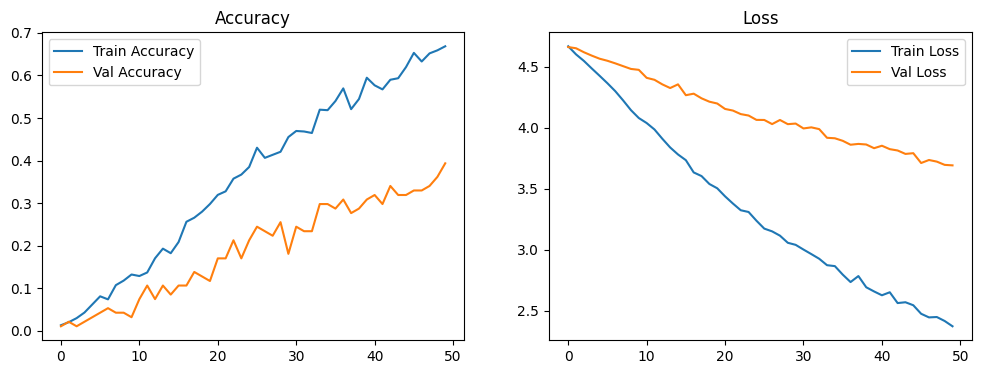

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

# Menyimpan Model

In [ ]:
os.makedirs('models', exist_ok=True)
model_cnn_lstm.save('models/sibi_model_rgb.keras')
print("Model berhasil disimpan di: models/sibi_model.keras")

Model berhasil disimpan di: models/sibi_model_rgb.keras
